In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
df = pd.read_csv("E:\ML Projects\Customer churn Ai\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df = df.drop("customerID", axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df = df.dropna()

In [19]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
df = df.dropna()

df.shape

(7032, 20)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

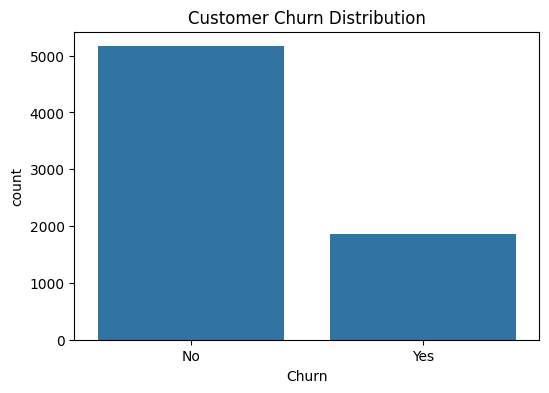

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.show()

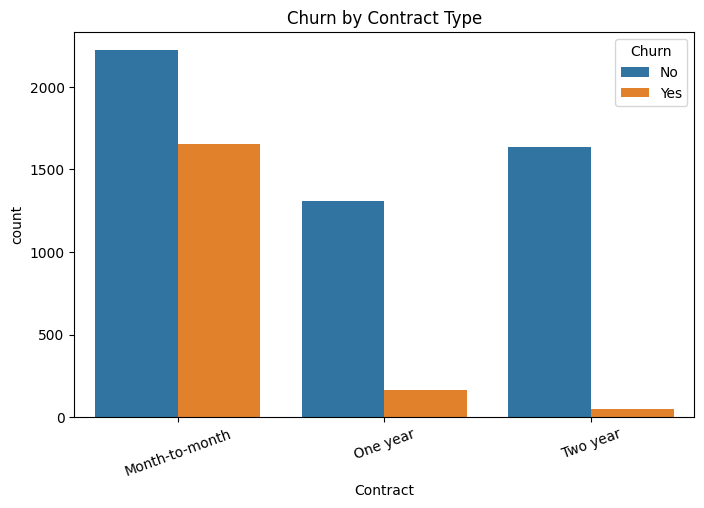

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

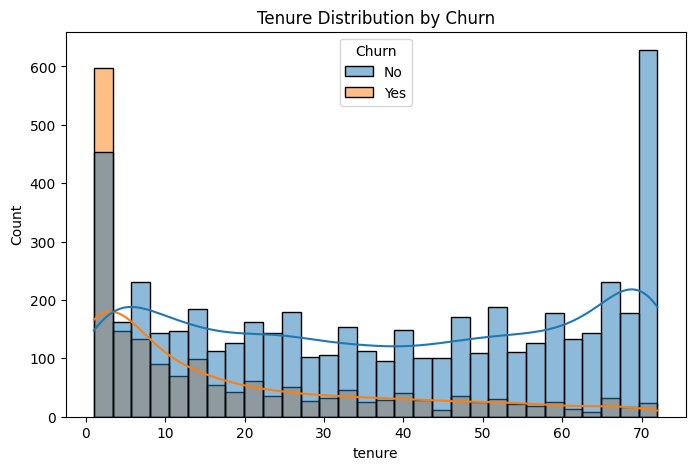

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.show()

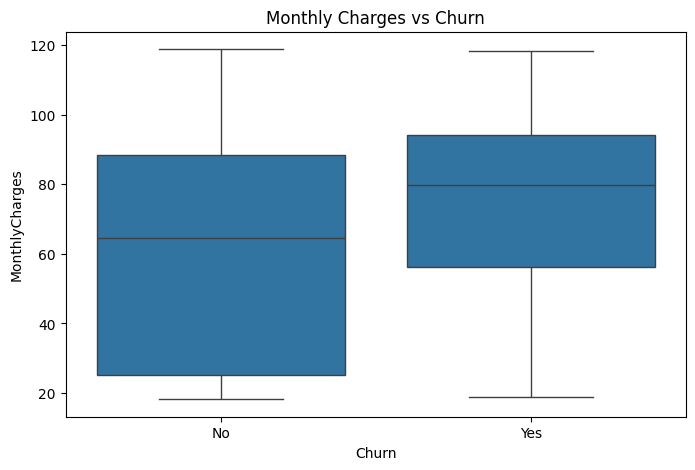

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

In [20]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [21]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [22]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [23]:
y = y.map({
    "No":0,
    "Yes":1
})

In [24]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [25]:
numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

In [26]:
numerical_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [27]:
categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [28]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
X_train.shape

(5625, 19)

In [30]:
X_test.shape

(1407, 19)

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [32]:
X_train_processed = preprocessor.fit_transform(X_train)

X_train_processed.shape

(5625, 45)

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_processed,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
X_test_processed = preprocessor.transform(X_test)

In [36]:
y_pred = model.predict(X_test_processed)

In [37]:
model.score(
    X_test_processed,
    y_test
)

0.8038379530916845

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



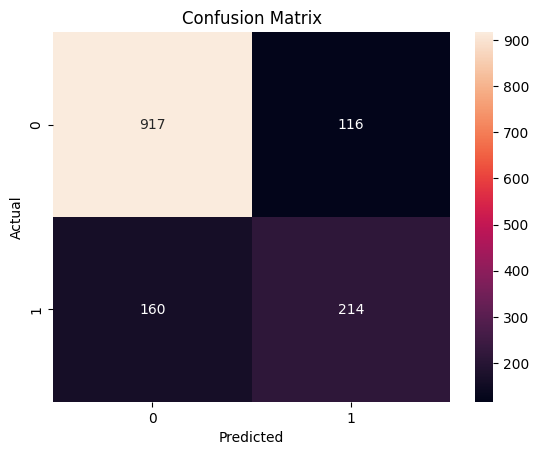

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_processed)[:,1]

roc_auc_score(y_test, y_prob)

0.8359290473207676

## Baseline Model: Logistic Regression

Accuracy: 80.4%
ROC-AUC: 0.836
F1-score (Churn): 0.61

Observation:
Model identifies churn customers moderately well but misses some churn cases.

In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [43]:
rf_model.fit(
    X_train_processed,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
rf_pred = rf_model.predict(
    X_test_processed
)

In [45]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [46]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(
    X_test_processed
)[:,1]

roc_auc_score(
    y_test,
    rf_prob
)

0.8139989957084653

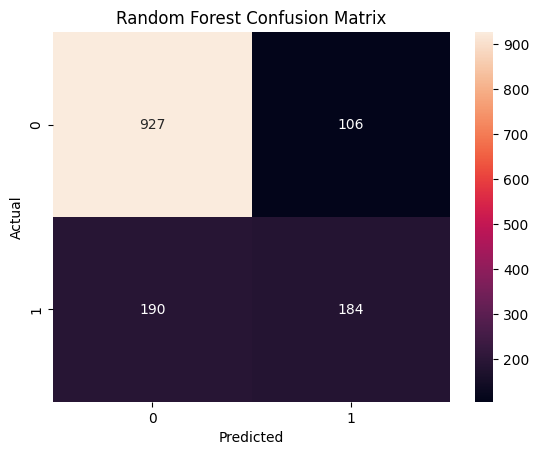

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Model Comparison

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | 80.4% | 0.836 |
| Random Forest | 79% | 0.814 |

Observation:
Logistic Regression currently performs better. More complex models require tuning.

In [48]:
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(
    X_train_processed,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
rf_balanced_pred = rf_balanced.predict(
    X_test_processed
)

In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_balanced_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



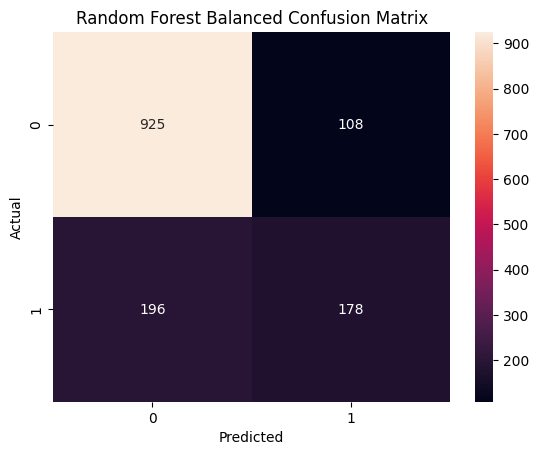

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_balanced_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Balanced Confusion Matrix")
plt.show()

In [52]:
from sklearn.metrics import roc_auc_score

rf_balanced_prob = rf_balanced.predict_proba(
    X_test_processed
)[:,1]

roc_auc = roc_auc_score(
    y_test,
    rf_balanced_prob
)

roc_auc

0.8116176858845271

In [53]:
rf_balanced_results = {
    "Model": "Random Forest Balanced",
    "Accuracy": rf_balanced.score(X_test_processed, y_test),
    "ROC-AUC": roc_auc
}

rf_balanced_results

{'Model': 'Random Forest Balanced',
 'Accuracy': 0.7839374555792467,
 'ROC-AUC': 0.8116176858845271}

## Random Forest Experiment

Default Random Forest:
ROC-AUC: 0.814
F1-score (Churn): 0.55

Balanced Random Forest:
ROC-AUC: 0.812
F1-score (Churn): 0.54

Observation:
Class weighting did not improve churn detection. Logistic Regression remains the strongest baseline so far.

In [54]:
from xgboost import XGBClassifier

In [55]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [56]:
xgb_model.fit(
    X_train_processed,
    y_train
)

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [57]:
xgb_pred = xgb_model.predict(
    X_test_processed
)

In [58]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407



In [59]:
from sklearn.metrics import roc_auc_score

xgb_prob = xgb_model.predict_proba(
    X_test_processed
)[:,1]

roc_auc = roc_auc_score(
    y_test,
    xgb_prob
)

roc_auc

0.8309127664090366

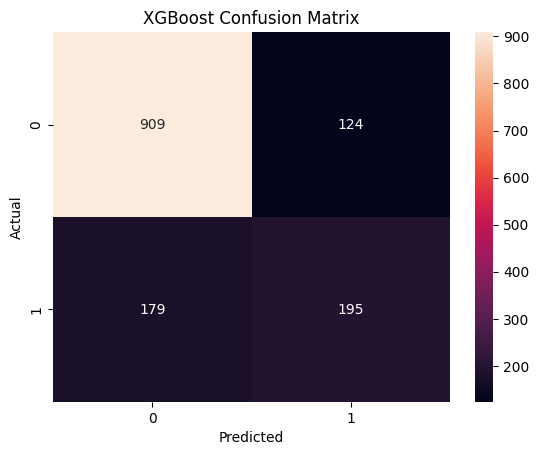

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    xgb_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [61]:
from collections import Counter

counter = Counter(y_train)

scale_weight = counter[0] / counter[1]

scale_weight

2.762541806020067

In [62]:
from xgboost import XGBClassifier


xgb_tuned = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric="logloss"
)

In [63]:
xgb_tuned.fit(
    X_train_processed,
    y_train
)

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [64]:
xgb_tuned_prob = xgb_tuned.predict_proba(
    X_test_processed
)[:,1]

In [65]:
from sklearn.metrics import classification_report


thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]


for threshold in thresholds:
    
    xgb_threshold_pred = (
        xgb_tuned_prob >= threshold
    ).astype(int)
    
    print("Threshold:", threshold)
    print(
        classification_report(
            y_test,
            xgb_threshold_pred
        )
    )
    print("----------------------")

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.94      0.58      0.72      1033
           1       0.43      0.90      0.59       374

    accuracy                           0.66      1407
   macro avg       0.69      0.74      0.65      1407
weighted avg       0.80      0.66      0.68      1407

----------------------
Threshold: 0.35
              precision    recall  f1-score   support

           0       0.93      0.61      0.74      1033
           1       0.45      0.87      0.59       374

    accuracy                           0.68      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.80      0.68      0.70      1407

----------------------
Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.64      0.76      1033
           1       0.46      0.84      0.60       374

    accuracy                           0.70      1407
   macro avg       0.69      0.74   

In [66]:
from sklearn.metrics import roc_auc_score

xgb_tuned_auc = roc_auc_score(
    y_test,
    xgb_tuned_prob
)

xgb_tuned_auc

0.8354501969757364

In [67]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost Tuned"
    ],
    "ROC-AUC": [
        0.836,
        0.814,
        xgb_tuned_auc
    ]
})

results

,Model,ROC-AUC
0,Logistic Regression,0.83600
1,Random Forest,0.81400
2,XGBoost Tuned,0.83545


# Final Model Selection

Models evaluated:

| Model | ROC-AUC |
|---|---|
| Logistic Regression | 0.836 |
| Random Forest | 0.814 |
| XGBoost Tuned | 0.836 |

Final Model:
XGBoost Tuned

Reason:
Although Logistic Regression achieved similar ROC-AUC,
XGBoost achieved significantly higher churn recall,
which is more aligned with the business objective of identifying
customers likely to leave.

In [68]:
import shap

explainer = shap.TreeExplainer(
    xgb_tuned
)

In [69]:
shap_values = explainer.shap_values(
    X_test_processed
)

In [70]:
print(xgboost.__version__)

1.7.6


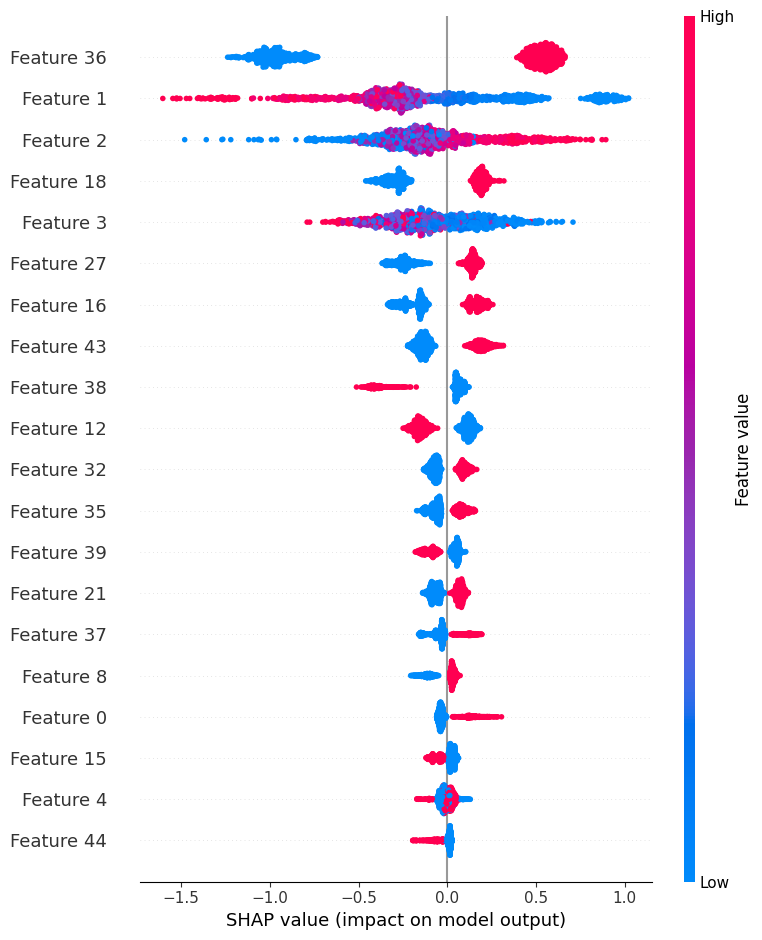

In [71]:
shap.summary_plot(
    shap_values,
    X_test_processed
)

In [72]:
feature_names = preprocessor.get_feature_names_out()

feature_names[:10]

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes'], dtype=object)

In [74]:
import pandas as pd

X_test_shap = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

X_test_shap.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,-0.439319,1.077320,0.363738,0.984674,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-0.439319,-1.041649,0.450100,-0.781798,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-0.439319,0.873573,-1.491376,-0.537223,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.439319,-1.245396,-1.473107,-0.994619,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-0.439319,1.566313,1.333645,2.308692,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


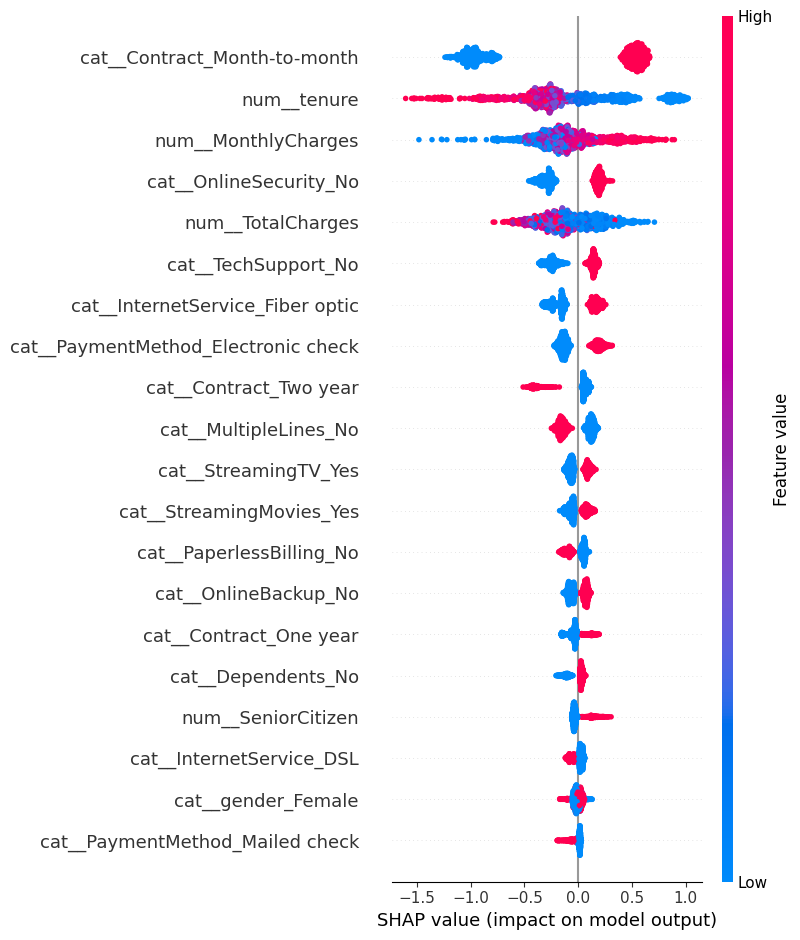

In [75]:
shap.summary_plot(
    shap_values,
    X_test_shap
)

In [76]:
customer_index = 0

In [77]:
customer_data = X_test_shap.iloc[[customer_index]]

customer_data

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,-0.439319,1.07732,0.363738,0.984674,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [79]:
customer_probability = xgb_tuned.predict_proba(
    X_test_processed[customer_index].reshape(1, -1)
)[0][1]


customer_probability

np.float32(0.05028302)

In [80]:
id="h8y7qa"

In [81]:
# Get churn probabilities for all test customers

all_probabilities = xgb_tuned.predict_proba(
    X_test_processed
)[:,1]


# Find the customer with highest churn probability

high_risk_index = all_probabilities.argmax()

high_risk_probability = all_probabilities[high_risk_index]


high_risk_probability

np.float32(0.9698612)

In [82]:
customer_index = high_risk_index

In [83]:
customer_data = X_test_shap.iloc[[customer_index]]

customer_probability = xgb_tuned.predict_proba(
    X_test_processed[customer_index].reshape(1,-1)
)[0][1]

customer_probability

np.float32(0.9698612)

In [86]:
print(f"Customer index: {customer_index}")

print(
    f"Churn probability: {customer_probability:.2%}"
)

Customer index: 1149
Churn probability: 96.99%


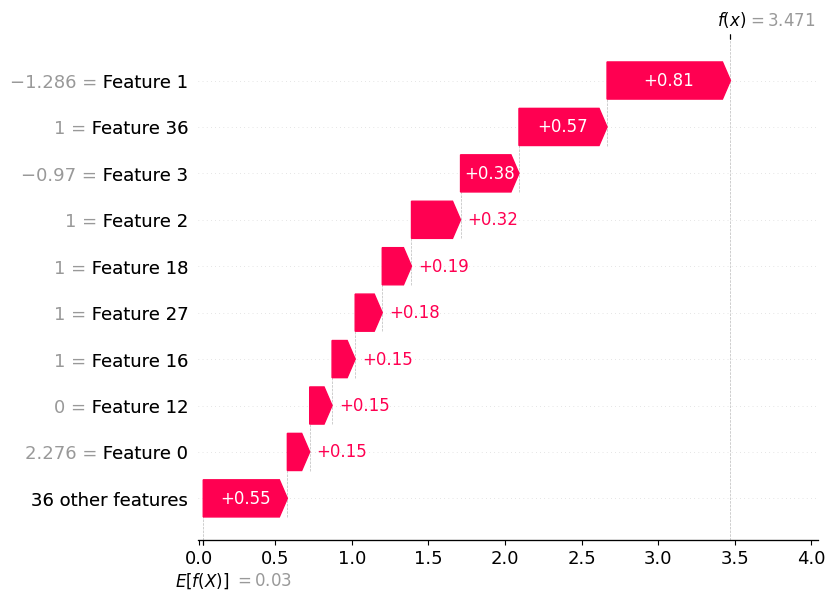

In [87]:
customer_explanation = explainer(
    X_test_processed[customer_index].reshape(1, -1)
)

shap.plots.waterfall(
    customer_explanation[0]
)

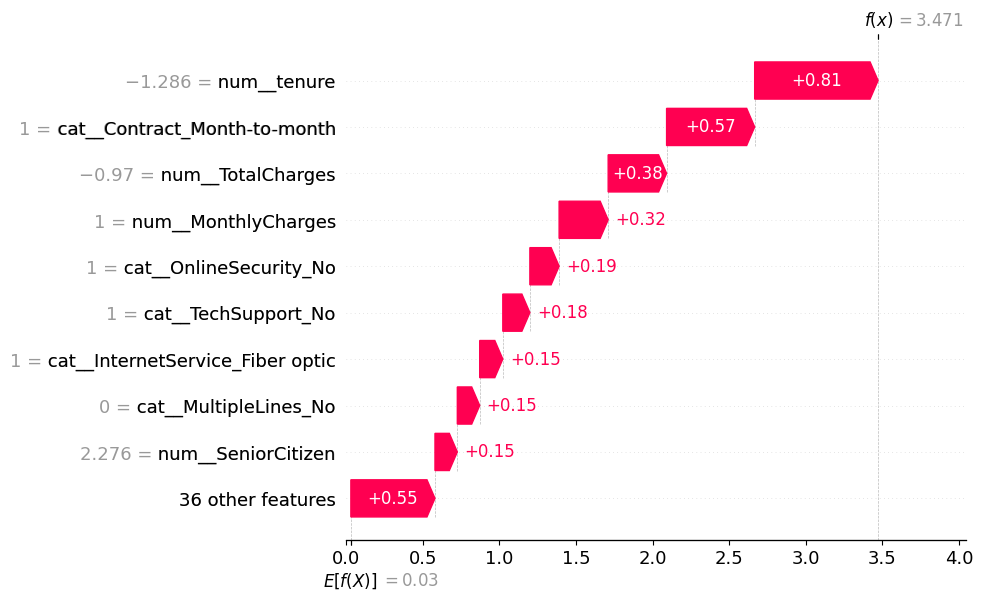

In [90]:
customer_explanation = explainer(
    X_test_shap.iloc[[customer_index]]
)

shap.plots.waterfall(
    customer_explanation[0]
)

In [91]:
import joblib

In [95]:
joblib.dump(
    xgb_tuned,
    "../models/xgb_churn_model.pkl"
)

['../models/xgb_churn_model.pkl']

In [96]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

['../models/preprocessor.pkl']

In [97]:
joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

['../models/feature_names.pkl']

In [98]:
import os

os.listdir("../models")

['feature_names.pkl', 'preprocessor.pkl', 'xgb_churn_model.pkl']

In [100]:
import joblib
import pandas as pd

In [101]:
model = joblib.load(
    "../models/xgb_churn_model.pkl"
)

preprocessor_loaded = joblib.load(
    "../models/preprocessor.pkl"
)

feature_names_loaded = joblib.load(
    "../models/feature_names.pkl"
)

In [102]:
def predict_churn(customer):

    # Convert dictionary to dataframe
    customer_df = pd.DataFrame([customer])

    # Apply preprocessing
    customer_processed = preprocessor_loaded.transform(
        customer_df
    )

    # Get probability
    probability = model.predict_proba(
        customer_processed
    )[0][1]

    # Classification
    prediction = (
        "Yes"
        if probability >= 0.5
        else "No"
    )

    return {
        "Churn Prediction": prediction,
        "Churn Probability": round(float(probability), 3)
    }

In [103]:
customer_example = {
    "gender":"Male",
    "SeniorCitizen":0,
    "Partner":"No",
    "Dependents":"No",
    "tenure":3,
    "PhoneService":"Yes",
    "MultipleLines":"No",
    "InternetService":"Fiber optic",
    "OnlineSecurity":"No",
    "OnlineBackup":"No",
    "DeviceProtection":"No",
    "TechSupport":"No",
    "StreamingTV":"Yes",
    "StreamingMovies":"Yes",
    "Contract":"Month-to-month",
    "PaperlessBilling":"Yes",
    "PaymentMethod":"Electronic check",
    "MonthlyCharges":95,
    "TotalCharges":285
}

In [104]:
predict_churn(customer_example)

{'Churn Prediction': 'Yes', 'Churn Probability': 0.909}

In [105]:
joblib.dump(
    explainer,
    "../models/shap_explainer.pkl"
)

['../models/shap_explainer.pkl']

In [109]:
explainer_loaded = joblib.load(
    "../models/shap_explainer.pkl"
)

In [ ]:
def explain_churn(customer):

    # Convert input to dataframe
    customer_df = pd.DataFrame([customer])

    # Preprocess
    customer_processed = preprocessor_loaded.transform(
        customer_df
    )

    # Prediction probability
    probability = model.predict_proba(
        customer_processed
    )[0][1]


    # SHAP explanation
    shap_result = explainer_loaded(
        customer_processed
    )

    shap_values = shap_result.values[0]


    # Create explanation table
    explanation = pd.DataFrame({
        "feature": feature_names_loaded,
        "impact": shap_values
    })


    # Absolute impact
    explanation["importance"] = abs(
        explanation["impact"]
    )


    # Top 5 reasons
    top_reasons = explanation.sort_values(
        "importance",
        ascending=False
    ).head(5)
 

    return {
        "Churn Probability": round(float(probability),3),
        "Prediction": (
            "Yes"
            if probability >= 0.5
            else "No"
        ),
        "Top Reasons": top_reasons[
            ["feature","impact"]
        ]
    }

In [111]:
explain_churn(customer_example)

{'Churn Probability': 0.909,
 'Prediction': 'Yes',
 'Top Reasons':                          feature    impact
 36  cat__Contract_Month-to-month  0.553715
 1                    num__tenure  0.420918
 2            num__MonthlyCharges  0.329335
 3              num__TotalCharges  0.229601
 12         cat__MultipleLines_No -0.223840}

In [139]:
def clean_feature_name(feature):

    # Remove pipeline prefixes
    feature = feature.replace("cat__", "")
    feature = feature.replace("num__", "")

    # Replace underscores
    feature = feature.replace("_", " ")


    replacements = {

        "Contract Month-to-month":
            "Month-to-Month Contract",

        "Contract One year":
            "One Year Contract",

        "Contract Two year":
            "Two Year Contract",

        "tenure":
            "Customer Tenure",

        "MonthlyCharges":
            "Monthly Charges",

        "TotalCharges":
            "Total Charges",

        "TechSupport No":
            "No Technical Support",

        "OnlineSecurity No":
            "No Online Security",

        "OnlineBackup No":
            "No Online Backup",

        "InternetService Fiber optic":
            "Fiber Optic Internet Service",

        "InternetService DSL":
            "DSL Internet Service",

        "MultipleLines No":
            "No Multiple Lines"

    }


    for old, new in replacements.items():

        feature = feature.replace(
            old,
            new
        )


    return feature

In [135]:
clean_feature_name("num__MonthlyCharges")

'Monthly Charges'

In [136]:
clean_feature_name("cat__MultipleLines_No")

'Multiple Lines No'

In [123]:
clean_feature_name("cat__Contract_Month-to-month")

'Contract Month-To-Month'

In [137]:
def explain_churn(customer):

    # Convert input to dataframe
    customer_df = pd.DataFrame([customer])

    # Preprocess
    customer_processed = preprocessor_loaded.transform(
        customer_df
    )

    # Prediction probability
    probability = model.predict_proba(
        customer_processed
    )[0][1]


    # SHAP explanation
    shap_result = explainer_loaded(
        customer_processed
    )

    shap_values = shap_result.values[0]


    # Create explanation table
    explanation = pd.DataFrame({
        "feature": feature_names_loaded,
        "impact": shap_values
    })


    # Absolute impact
    explanation["importance"] = abs(
        explanation["impact"]
    )


    # Top 5 reasons
    top_reasons = explanation.sort_values(
        "importance",
        ascending=False
    ).head(5)
 
    top_reasons["feature"] = (
    top_reasons["feature"]
    .apply(clean_feature_name)
    )
    return {
        "Churn Probability": round(float(probability),3),
        "Prediction": (
            "Yes"
            if probability >= 0.5
            else "No"
        ),
        "Top Reasons": top_reasons[
            ["feature","impact"]
        ]
    }

In [138]:
explain_churn(customer_example)

{'Churn Probability': 0.909,
 'Prediction': 'Yes',
 'Top Reasons':                     feature    impact
 36  Month-To-Month Contract  0.553715
 1           Customer Tenure  0.420918
 2           Monthly Charges  0.329335
 3             Total Charges  0.229601
 12        Multiple Lines No -0.223840}